# Two-State Adaptive Simplex MF-REINFORCE Comparison

This notebook compares fixed simplex MF-REINFORCE, finite-budget adaptive simplex MF-REINFORCE, consistent adaptive simplex MF-REINFORCE, and logit-perturbed MF-REINFORCE on the two-state two-action benchmark.

The default configuration below uses the paper-scale exact-flow setup with equal simulator budgets: simplex-family methods use `B=2800`, `n_aux=400`, and logits uses `B=200`, `n=10`.

## Imports

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = (ROOT / "..").resolve()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from mfc.algorithms import AdaptiveSimplexControllerConfig
from mfc.experiments import (
    TwoStateAdaptiveComparisonConfig,
    controller_diagnostics_frame,
    run_twostate_adaptive_comparison,
    summarize_comparison_results,
    tiny_twostate_adaptive_comparison_config,
)


## Paper-Scale Defaults

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float64
torch.set_default_dtype(DTYPE)
adaptive_initial_lambdas = (0.05, 0.1, 0.15, 0.2)

paper_config = TwoStateAdaptiveComparisonConfig(
    device=device,
    dtype=DTYPE,
    n_train=10_000,
    training_runs=5,
    validate_every=10,
    B=2800,
    n_aux=400,
    logit_B=200,
    logit_n=10,
    simplex_lambdas=(0.1, 0.2, 0.4, 0.8),
    logit_epsilons=(0.2, 0.5, 1.0, 2.0),
    adaptive_initial_lambdas=adaptive_initial_lambdas,
    finite_controller=AdaptiveSimplexControllerConfig(
        initial_lambda=adaptive_initial_lambdas[0],
        lambda_min=0.01,
        lambda_max=0.8,
        checkpoint_interval=100,
        diagnostic_replications=4,
        contraction=0.5,
    ),
    consistent_controller=AdaptiveSimplexControllerConfig(
        initial_lambda=adaptive_initial_lambdas[0],
        lambda_min=0.01,
        lambda_max=0.8,
        checkpoint_interval=100,
        diagnostic_replications=4,
        contraction=0.5,
        envelope_lambda0=adaptive_initial_lambdas[0],
        envelope_m0=1000.0,
        envelope_zeta=0.25,
        eta_power=1.5,
        main_sample_growth_power=0.25,
        aux_sample_growth_power=0.5,
        sample_growth_interval=1000.0,
    ),
)

display(pd.DataFrame([
    {
        "device": str(device),
        "n_train": paper_config.n_train,
        "training_runs": paper_config.training_runs,
        "simplex_B": paper_config.B,
        "simplex_n_aux": paper_config.n_aux,
        "logit_B": paper_config.logit_B,
        "logit_n": paper_config.logit_n,
        "adaptive_initial_lambdas": list(paper_config.adaptive_initial_lambdas),
        "simplex_lambdas": list(paper_config.simplex_lambdas),
        "logit_epsilons": list(paper_config.logit_epsilons),
    }
]))


,device,n_train,training_runs,simplex_B,simplex_n_aux,logit_B,logit_n,adaptive_initial_lambdas,simplex_lambdas,logit_epsilons
0,cuda,10000,5,2800,400,200,10,"[0.05, 0.1, 0.15, 0.2]","[0.1, 0.2, 0.4, 0.8]","[0.2, 0.5, 1.0, 2.0]"


## Tiny Smoke Run

In [3]:
smoke_config = tiny_twostate_adaptive_comparison_config(device, DTYPE)
smoke_results = run_twostate_adaptive_comparison(smoke_config, show_progress=False)
display(summarize_comparison_results(smoke_results).round(6))
display(controller_diagnostics_frame(smoke_results).round(6))


,algorithm,parameter,runs,B,n_aux_or_inner,value_mean,value_std,policy_error_mean,flow_error_mean,total_simulator_transitions_mean
0,Fixed Simplex,0.2,1,3,2,-5.000642,0.0,0.275070,0.082779,20.0
1,Finite Adaptive Simplex,0.2,1,3,2,-5.005432,0.0,0.275251,0.083019,60.0
2,Consistent Adaptive Simplex,0.2,1,3,2,-5.005424,0.0,0.275251,0.083019,72.0
3,Logits,0.2,1,3,2,-4.992362,0.0,0.275015,0.082363,48.0


,algorithm,parameter,run_idx,episode,lambda_plus,lambda_minus,eta_plus,eta_minus,bias_proxy_sq,variance_proxy,delta_covariance_trace,mean_delta_norm,signed_pressure,directional_cosine,direction_triggered,lambda_ctrl_after,rho_after
0,Finite Adaptive Simplex,0.2,0,0,0.200000,0.100000,0.200000,0.100000,236.714979,0.0,0.0,7.692772,33.097878,0.986595,False,0.194608,-1.030829
1,Finite Adaptive Simplex,0.2,0,1,0.194608,0.097304,0.194608,0.097304,10056.657317,0.0,0.0,50.141443,36.847011,0.999513,False,0.189335,-1.080897
2,Consistent Adaptive Simplex,0.2,0,0,0.200000,0.100000,0.089443,0.031623,2695.180977,0.0,0.0,25.957566,35.530242,0.995479,False,0.194608,-1.030829
3,Consistent Adaptive Simplex,0.2,0,1,0.194608,0.097304,0.085850,0.030353,421058.551638,0.0,0.0,324.445123,40.581548,0.999820,False,0.189335,-1.080892


## Full Comparison

In [4]:
results = run_twostate_adaptive_comparison(paper_config, show_progress=True)
summary = summarize_comparison_results(results)
diagnostics = controller_diagnostics_frame(results)

display(summary.round(6))
display(diagnostics.round(6).head(20))


Logits 2.0 run=4: 100%|██████████| 10000/10000 [03:06<00:00, 53.49it/s, grad=0.217, value=-5.537]


,algorithm,parameter,runs,B,n_aux_or_inner,value_mean,value_std,policy_error_mean,flow_error_mean,total_simulator_transitions_mean
0,Fixed Simplex,0.10,5,2800,400,-3.568644,0.015052,0.016287,0.010217,64000000.0
1,Fixed Simplex,0.20,5,2800,400,-3.806555,0.012819,0.035177,0.021843,64000000.0
2,Fixed Simplex,0.40,5,2800,400,-4.371273,0.015047,0.080289,0.049334,64000000.0
3,Fixed Simplex,0.80,5,2800,400,-6.139826,0.073136,0.132399,0.139777,64000000.0
4,Finite Adaptive Simplex,0.05,5,2800,400,-3.852604,0.051060,0.040110,0.024090,69120000.0
5,Finite Adaptive Simplex,0.10,5,2800,400,-3.874307,0.057549,0.040655,0.025148,69120000.0
6,Finite Adaptive Simplex,0.15,5,2800,400,-3.864597,0.077928,0.039740,0.024674,69120000.0
7,Finite Adaptive Simplex,0.20,5,2800,400,-3.851206,0.070983,0.038691,0.024021,69120000.0
8,Consistent Adaptive Simplex,0.05,5,2800,400,-4.531736,0.176796,0.220065,0.059241,112518462.0
9,Consistent Adaptive Simplex,0.10,5,2800,400,-3.760756,0.074847,0.090093,0.020267,112518462.0


,algorithm,parameter,run_idx,episode,lambda_plus,lambda_minus,eta_plus,eta_minus,bias_proxy_sq,variance_proxy,delta_covariance_trace,mean_delta_norm,signed_pressure,directional_cosine,direction_triggered,lambda_ctrl_after,rho_after
0,Finite Adaptive Simplex,0.05,0,0,0.050000,0.025000,0.050000,0.025000,0.000000,44.592574,97.937821,3.209357,-31.428588,0.999898,False,0.051942,-2.881194
1,Finite Adaptive Simplex,0.05,0,100,0.051942,0.025971,0.051942,0.025971,0.000000,22.395060,47.807014,3.086340,1.000000,-0.922130,True,0.053244,-2.848892
2,Finite Adaptive Simplex,0.05,0,200,0.053244,0.026622,0.053244,0.026622,63.551718,11.183902,18.574725,4.531182,1.737379,0.999786,False,0.054200,-2.825724
3,Finite Adaptive Simplex,0.05,0,300,0.054200,0.027100,0.054200,0.027100,136.111787,45.734669,39.734062,6.630344,1.090620,0.957027,False,0.054956,-2.807765
4,Finite Adaptive Simplex,0.05,0,400,0.054956,0.027478,0.054956,0.027478,107.299513,53.105377,63.496897,6.534455,0.703346,0.999753,False,0.055577,-2.793199
5,Finite Adaptive Simplex,0.05,0,500,0.055577,0.027789,0.055577,0.027789,0.000000,50.717662,114.262803,1.055390,-31.557295,0.644769,False,0.056766,-2.765845
6,Finite Adaptive Simplex,0.05,0,600,0.056766,0.028383,0.056766,0.028383,0.034232,5.924277,2.210328,0.749093,-5.153666,0.997509,False,0.057952,-2.739204
7,Finite Adaptive Simplex,0.05,0,700,0.057952,0.028976,0.057952,0.028976,23.561659,6.300735,9.273324,2.865091,1.318954,0.999997,False,0.058987,-2.716457
8,Finite Adaptive Simplex,0.05,0,800,0.058987,0.029494,0.058987,0.029494,0.000000,39.873926,50.599444,0.788074,-31.316744,0.999774,False,0.060410,-2.685906
9,Finite Adaptive Simplex,0.05,0,900,0.060410,0.030205,0.060410,0.030205,0.000000,0.214598,3.787551,0.164140,-26.092031,0.997997,False,0.062089,-2.650863


## Plots

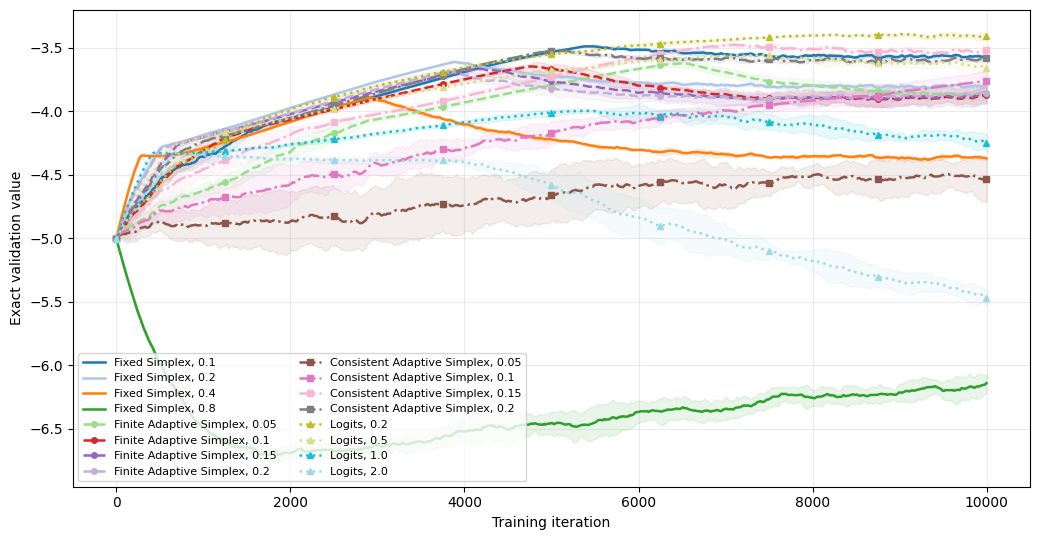

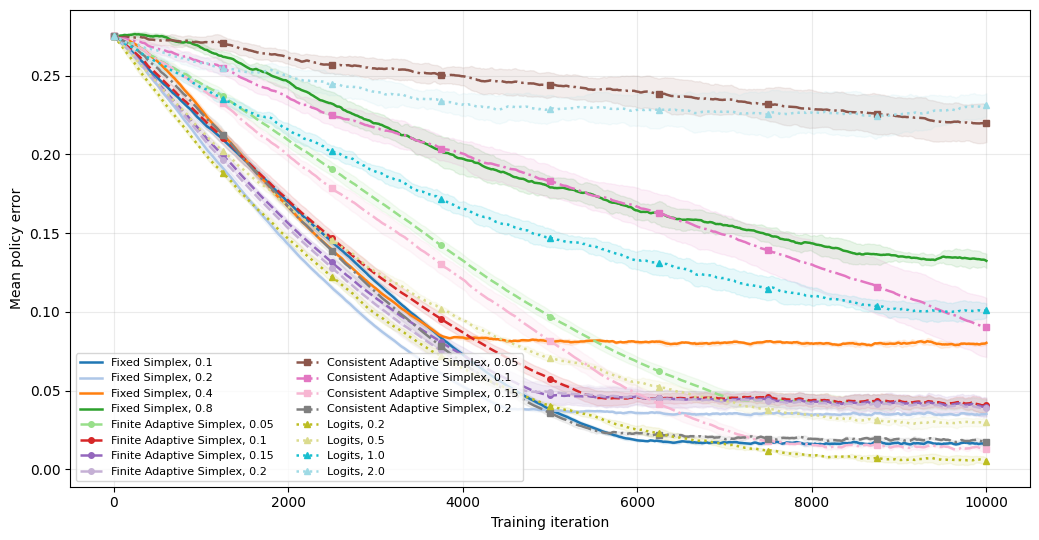

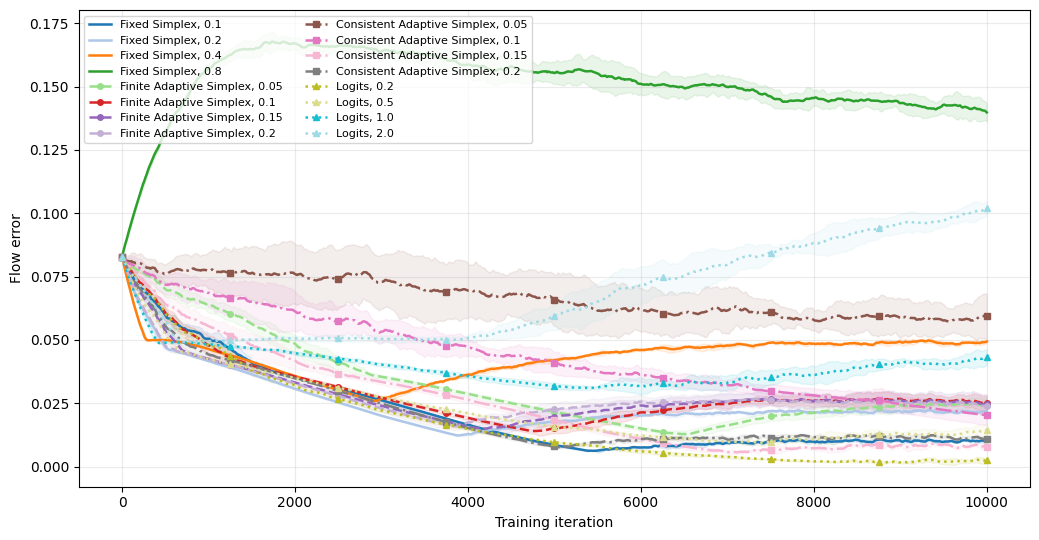

In [7]:
def _aligned_history(runs, key):
    lengths = [len(run["history"].get(key, [])) for run in runs]
    if not lengths or min(lengths) == 0:
        return np.asarray([]), np.asarray([])
    count = min(lengths)
    episodes = np.asarray(runs[0]["history"]["episode"][:count], dtype=float)
    values = np.asarray([run["history"][key][:count] for run in runs], dtype=float)
    return episodes, values

LINE_STYLES = {
    "Fixed Simplex": "-",
    "Finite Adaptive Simplex": "--",
    "Consistent Adaptive Simplex": "-.",
    "Logits": ":",
}

MARKERS = {
    "Fixed Simplex": None,
    "Finite Adaptive Simplex": "o",
    "Consistent Adaptive Simplex": "s",
    "Logits": "^",
}

def _curve_keys(results, algorithm_filter=None):
    keys = []
    for algorithm_name, parameter_groups in results.items():
        if algorithm_filter is not None and algorithm_name not in algorithm_filter:
            continue
        for parameter in parameter_groups:
            keys.append((algorithm_name, parameter))
    return keys

def _curve_color_map(keys, cmap_name="tab20"):
    cmap = plt.get_cmap(cmap_name, max(len(keys), 1))
    return {key: cmap(i) for i, key in enumerate(keys)}

comparison_curve_colors = _curve_color_map(_curve_keys(results))
adaptive_curve_colors = _curve_color_map(
    _curve_keys(results, {"Finite Adaptive Simplex", "Consistent Adaptive Simplex"}),
    cmap_name="Dark2",
)

def plot_metric(results, key, ylabel):
    fig, ax = plt.subplots(figsize=(10.5, 5.5))
    for algorithm_name, parameter_groups in results.items():
        for parameter, runs in parameter_groups.items():
            episodes, values = _aligned_history(runs, key)
            if values.size == 0:
                continue
            mean = values.mean(axis=0)
            std = values.std(axis=0, ddof=1 if len(runs) > 1 else 0)
            curve_key = (algorithm_name, parameter)
            label = f"{algorithm_name}, {parameter}"
            color = comparison_curve_colors[curve_key]
            ax.plot(
                episodes,
                mean,
                label=label,
                color=color,
                linestyle=LINE_STYLES.get(algorithm_name, "-"),
                marker=MARKERS.get(algorithm_name),
                markevery=max(len(episodes) // 8, 1),
                markersize=4,
                linewidth=1.8,
            )
            ax.fill_between(episodes, mean - std, mean + std, color=color, alpha=0.10)
    ax.set_xlabel("Training iteration")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, ncol=2)
    fig.tight_layout()
    plt.show()

plot_metric(results, "validation_value", "Exact validation value")
plot_metric(results, "policy_error_mean", "Mean policy error")
plot_metric(results, "flow_error", "Flow error")


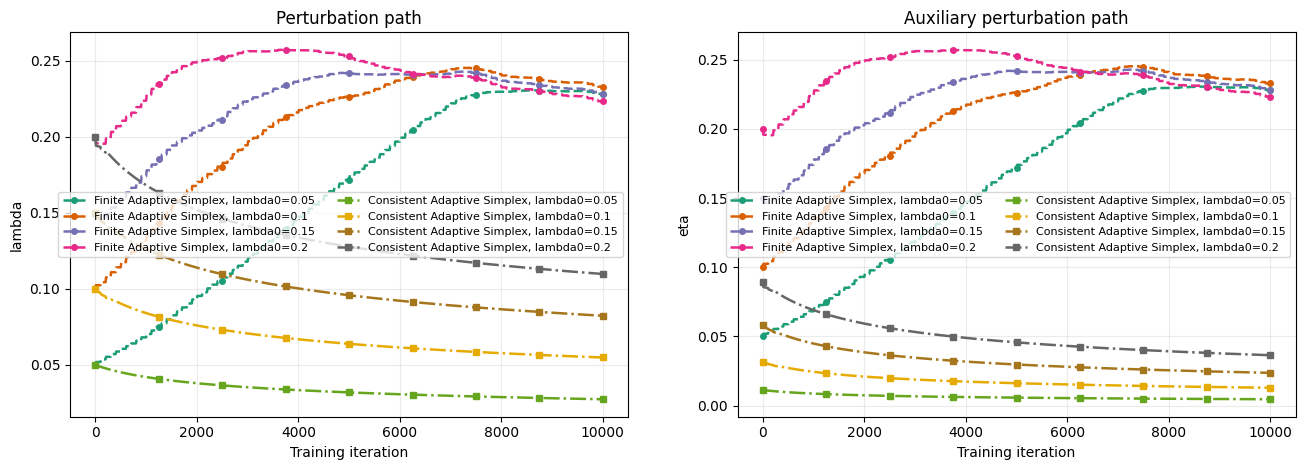

,algorithm,run_idx,episode,lambda_plus,lambda_minus,bias_proxy_sq,variance_proxy,signed_pressure,directional_cosine,direction_triggered
0,Finite Adaptive Simplex,0,0,0.050000,0.025000,0.000000,44.592574,-31.428588,0.999898,False
1,Finite Adaptive Simplex,0,100,0.051942,0.025971,0.000000,22.395060,1.000000,-0.922130,True
2,Finite Adaptive Simplex,0,200,0.053244,0.026622,63.551718,11.183902,1.737379,0.999786,False
3,Finite Adaptive Simplex,0,300,0.054200,0.027100,136.111787,45.734669,1.090620,0.957027,False
4,Finite Adaptive Simplex,0,400,0.054956,0.027478,107.299513,53.105377,0.703346,0.999753,False
...,...,...,...,...,...,...,...,...,...,...
3995,Consistent Adaptive Simplex,4,9500,0.111105,0.055552,0.000000,0.022620,1.000000,-0.500369,True
3996,Consistent Adaptive Simplex,4,9600,0.110842,0.055421,0.000000,0.257005,1.000000,-0.995852,True
3997,Consistent Adaptive Simplex,4,9700,0.110582,0.055291,11.002654,0.232080,3.858809,-0.997937,True
3998,Consistent Adaptive Simplex,4,9800,0.110325,0.055163,0.000000,0.522740,1.000000,-0.971395,True


In [8]:
adaptive_names = ["Finite Adaptive Simplex", "Consistent Adaptive Simplex"]
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
for algorithm_name in adaptive_names:
    for initial_lambda, runs in results[algorithm_name].items():
        episodes, lambdas = _aligned_history(runs, "lambda")
        _, etas = _aligned_history(runs, "eta")
        curve_key = (algorithm_name, initial_lambda)
        label = f"{algorithm_name}, lambda0={initial_lambda}"
        color = adaptive_curve_colors[curve_key]
        style = LINE_STYLES.get(algorithm_name, "-")
        marker = MARKERS.get(algorithm_name)
        markevery = max(len(episodes) // 8, 1) if episodes.size else 1
        if lambdas.size:
            axes[0].plot(
                episodes,
                lambdas.mean(axis=0),
                label=label,
                color=color,
                linestyle=style,
                marker=marker,
                markevery=markevery,
                markersize=4,
                linewidth=1.8,
            )
        if etas.size:
            axes[1].plot(
                episodes,
                etas.mean(axis=0),
                label=label,
                color=color,
                linestyle=style,
                marker=marker,
                markevery=markevery,
                markersize=4,
                linewidth=1.8,
            )

axes[0].set_title("Perturbation path")
axes[0].set_xlabel("Training iteration")
axes[0].set_ylabel("lambda")
axes[1].set_title("Auxiliary perturbation path")
axes[1].set_xlabel("Training iteration")
axes[1].set_ylabel("eta")
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

if not diagnostics.empty:
    display(diagnostics[[
        "algorithm",
        "run_idx",
        "episode",
        "lambda_plus",
        "lambda_minus",
        "bias_proxy_sq",
        "variance_proxy",
        "signed_pressure",
        "directional_cosine",
        "direction_triggered",
    ]].round(6))
